In [1]:
from scipy.io import netcdf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import datetime as dt
import cartopy.crs as ccrs
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import pandas as pd
import glob
import copy
import pickle
import matplotlib.path as mpath
from netCDF4 import Dataset
import xarray as xr


In [2]:
datasets = ["ERA5", "MERRA2", "JRA3Q"]

OUT_DIR_List = {
    "ERA5": "/scratch/bell/hu1029/LGHW/interm_ERA5",
    "MERRA2": "/scratch/bell/hu1029/LGHW/interm_MERRA2",
    "JRA3Q": "/scratch/bell/hu1029/LGHW/interm_JRA3Q"
}
yearnameList = {
    "ERA5": "1979_2025",
    "MERRA2": "1980_2025",
    "JRA3Q": "1979_2025"
}
timerefFile = {
    "ERA5": "/scratch/bell/hu1029/Data/processed/ERA5_Z500_6hr_1979_2025_1dg.nc",
    "MERRA2": "/scratch/bell/hu1029/Data/processed/MERRA2_Z500_6hr_1980_2025_1dg.nc",
    "JRA3Q": "/scratch/bell/hu1029/Data/processed/JRA3Q_Z500_6hr_1979_2025_1dg.nc"
}
latrefFile = {
    "ERA5": "/scratch/bell/hu1029/LGHW/interm_ERA5/ERA5_LWA_lat_1979_2025_6hr.npy",
    "MERRA2": "/scratch/bell/hu1029/LGHW/interm_MERRA2/MERRA2_LWA_lat_1980_2025_6hr.npy",
    "JRA3Q": "/scratch/bell/hu1029/LGHW/interm_JRA3Q/JRA3Q_LWA_lat_1979_2025_6hr.npy"
}
lonrefFile = {
    "ERA5": "/scratch/bell/hu1029/LGHW/interm_ERA5/ERA5_LWA_lon_1979_2025_6hr.npy",
    "MERRA2": "/scratch/bell/hu1029/LGHW/interm_MERRA2/MERRA2_LWA_lon_1980_2025_6hr.npy",
    "JRA3Q": "/scratch/bell/hu1029/LGHW/interm_JRA3Q/JRA3Q_LWA_lon_1979_2025_6hr.npy"
}
TRACK_latrefFile = {
    "ERA5": "/scratch/bell/hu1029/LGHW/interm_ERA5/ERA5_TRACK_lat_1979_2025_6hr.npy",
    "MERRA2": "/scratch/bell/hu1029/LGHW/interm_MERRA2/MERRA2_TRACK_lat_1980_2025_6hr.npy",
    "JRA3Q": "/scratch/bell/hu1029/LGHW/interm_JRA3Q/JRA3Q_TRACK_lat_1979_2025_6hr.npy"
}
TRACK_lonrefFile = {
    "ERA5": "/scratch/bell/hu1029/LGHW/interm_ERA5/ERA5_TRACK_lon_1979_2025_6hr.npy",
    "MERRA2": "/scratch/bell/hu1029/LGHW/interm_MERRA2/MERRA2_TRACK_lon_1980_2025_6hr.npy",
    "JRA3Q": "/scratch/bell/hu1029/LGHW/interm_JRA3Q/JRA3Q_TRACK_lon_1979_2025_6hr.npy"
}

In [ ]:
# %% 00 function preparation --------------------------------
regions = ["ATL", "NP", "SP"]
seasons = [ "ALL", "DJF", "JJA"]
seasonsmonths = [[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], [12, 1, 2], [6, 7, 8]]
blkTypes = ["Ridge", "Trough", "Dipole"]
cycTypes = ["AC", "CC"]

def Region_ERA(regionname): 
    if regionname == "ATL": 
        lat_min, lat_max, lon_min, lon_max = 45, 75, 300, 60
    elif regionname == "NP": 
        lat_min, lat_max, lon_min, lon_max = 40, 70, 130, 250
    elif regionname == "SP": 
        lat_min, lat_max, lon_min, lon_max = -75, -45, 180, 300
    return lat_min, lat_max, lon_min, lon_max

def PlotBoundary(regionname): 
    if regionname == "ATL": 
        lat_min, lat_max, lon_min, lon_max, loncenter = 30, 90, 250, 90, 350
    elif regionname == "NP": 
        lat_min, lat_max, lon_min, lon_max, loncenter = 30, 90, 80, 280, 180
    elif regionname == "SP": 
        lat_min, lat_max, lon_min, lon_max, loncenter = -90, -30, 130, 330, 230

    return lat_min, lat_max, lon_min, lon_max, loncenter

def findClosest(lati, latids):

    if isinstance(lati, (np.ndarray, list)):  # if lat is an array or list
        closest_indices = []
        for l in lati:  
            diff = np.abs(l - latids)
            closest_idx = np.argmin(diff) 
            closest_indices.append(closest_idx)
        return closest_indices
    else:
        # if lat is a single value
        diff = np.abs(lati - latids)
        return np.argmin(diff) 

In [4]:
# import numpy as np
# import pickle
# import pandas as pd
# from scipy.stats import linregress

# dtname = "ERA5"
# eve = "Seeding"    
# k = "NH"            
# OUT_DIR = OUT_DIR_List[dtname]
# timereff = timerefFile[dtname]
# latref = latrefFile[dtname]
# lonref = lonrefFile[dtname]
# yearname = yearnameList[dtname]

# # ============================================================
# # 0. Basic settings
# # ============================================================

# ### Time Management ###
# start_year, end_year = map(int, yearname.split('_'))
# Datestamp = pd.date_range(start=f"{start_year}-01-01", end=f"{end_year}-12-31")
# Date0 = pd.DataFrame({'date': pd.to_datetime(Datestamp)})
# Date = list(Date0['date'])
# nday = len(Date)
# Month = Date0['date'].dt.month
# Year = Date0['date'].dt.year
# Day = Date0['date'].dt.day
# # ============================================================
# # 1. Read blocking event data
# # ============================================================

# with open(f"{OUT_DIR}/{dtname}_SD_{eve}_diversity_label_daily_{k}", "rb") as fp:
#     Blocking_diversity_label = pickle.load(fp)

# with open(f"{OUT_DIR}/{dtname}_SD_{eve}_diversity_date_daily_{k}", "rb") as fp:
#     Blocking_diversity_date = pickle.load(fp)

# print("Number of blocking types:", len(Blocking_diversity_label))
# print("Number of date types:", len(Blocking_diversity_date))

# # ============================================================
# # 2. Get grid size
# # ============================================================

# sample_label = None

# for event_labels in Blocking_diversity_label:
#     # event_labels = [Ridge_list, Trough_list, Dipole_list]
#     for type_labels in event_labels:
#         if len(type_labels) > 0:
#             sample_label = np.asarray(type_labels[0])
#             break
#     if sample_label is not None:
#         break

# if sample_label is None or sample_label.ndim != 2:
#     raise ValueError("No valid 2D label array found.")

# nlat, nlon = sample_label.shape
# ntime = len(Date)

# print("ntime, nlat, nlon =", ntime, nlat, nlon)

# # ============================================================
# # Reconstruct 3D array: time × lat × lon
# # Merge Ridge/Trough/Dipole together
# # Structure:
# # Blocking_diversity_date[itype][ievent][iday]
# # Blocking_diversity_label[itype][ievent][iday]
# # ============================================================

# blk_all = np.zeros((ntime, nlat, nlon), dtype=np.float32)

# date_to_idx = {
#     pd.Timestamp(d).normalize(): i
#     for i, d in enumerate(Date)
# }

# ntype = 3

# for itype in range(ntype):

#     type_dates_all = Blocking_diversity_date[itype]
#     type_labels_all = Blocking_diversity_label[itype]

#     print(f"Processing type {itype}: {len(type_dates_all)} events")

#     if len(type_dates_all) != len(type_labels_all):
#         print(
#             f"Warning: type {itype} event number mismatch:",
#             len(type_dates_all), len(type_labels_all)
#         )

#     for event_dates, event_labels in zip(type_dates_all, type_labels_all):

#         if len(event_dates) != len(event_labels):
#             print(
#                 f"Warning: type {itype} date/label length mismatch:",
#                 len(event_dates), len(event_labels)
#             )

#         for d, lab in zip(event_dates, event_labels):

#             d = pd.Timestamp(d).normalize()

#             if d not in date_to_idx:
#                 continue

#             t = date_to_idx[d]

#             mask = (np.asarray(lab) > 0).astype(np.float32)

#             # merge all 3 types and overlapping events into one binary mask
#             blk_all[t, :, :] = np.maximum(blk_all[t, :, :], mask)

# print("blk_all shape:", blk_all.shape)
# print("Total blocked grid-time points:", np.nansum(blk_all))

# # ============================================================
# # 4. Read BAM index
# # ============================================================

# if k == "NH":
#     BI = np.load(f"{OUT_DIR}/{dtname}_NH_BAM_index_total_with_leap.npy")
# else:
#     BI = np.load(f"{OUT_DIR}/{dtname}_SH_BAM_index_total_with_leap.npy")

# BI = np.asarray(BI).astype(np.float64)

# print("BI shape:", BI.shape)

# # ============================================================
# # # 5. Align time length
# # # ============================================================

# # nt = min(len(BI), blk_all.shape[0])

# # BI = BI[:nt]
# # blk_all = blk_all[:nt, :, :]
# # Date_used = Date0[:nt]
# # print("After alignment:")
# print("BI:", BI.shape)
# print("blk_all:", blk_all.shape)

# # ============================================================
# # 6. Standardize BAM index
# #    If your BI is already standardized, this step is still okay
# #    but you can skip it if needed.
# # ============================================================

# # BI_std = (BI - np.nanmean(BI)) / np.nanstd(BI)

# # ============================================================
# # 7. Regression: blocking occurrence onto BAM index
# # ============================================================

# blk_anom = blk_all - np.mean(blk_all, axis=0, keepdims=True)

# ntime, nlat, nlon = blk_all.shape
# # blk_2d = blk_all.reshape(ntime, nlat * nlon)
# blk_2d = blk_anom.reshape(ntime, -1)

# slope = np.full(nlat * nlon, np.nan, dtype=np.float64)
# intercept = np.full(nlat * nlon, np.nan, dtype=np.float64)
# rval = np.full(nlat * nlon, np.nan, dtype=np.float64)
# pval = np.full(nlat * nlon, np.nan, dtype=np.float64)

# for i in range(nlat * nlon):

#     y = blk_2d[:, i]
#     x = BI

#     mask = np.isfinite(x) & np.isfinite(y)

#     if mask.sum() < 10:
#         continue

#     # skip grid points with no blocking at all
#     if np.nanstd(y[mask]) == 0:
#         continue

#     res = linregress(x[mask], y[mask])

#     slope[i] = res.slope
#     intercept[i] = res.intercept
#     rval[i] = res.rvalue
#     pval[i] = res.pvalue

# slope = slope.reshape(nlat, nlon)
# intercept = intercept.reshape(nlat, nlon)
# rval = rval.reshape(nlat, nlon)
# pval = pval.reshape(nlat, nlon)

# # convert probability change to percentage points per 1 std BAM
# slope_pct = slope * 100.0

# print("Regression done.")
# print("slope_pct min/max:", np.nanmin(slope_pct), np.nanmax(slope_pct))

# # ============================================================
# # 8. Optional: save results
# # ============================================================

# # np.save(f"{OUT_DIR}/{dtname}_{kk}_{eve}_{k}_blocking_regress_on_BAM_slope_pct.npy", slope_pct)
# # np.save(f"{OUT_DIR}/{dtname}_{kk}_{eve}_{k}_blocking_regress_on_BAM_pval.npy", pval)
# # np.save(f"{OUT_DIR}/{dtname}_{kk}_{eve}_{k}_blocking_daily_binary_1979_2025.npy", blk_all)

# # print("Saved slope_pct, pval, and reconstructed daily blocking mask.")

In [5]:
import numpy as np
import pickle
import pandas as pd
from scipy.stats import linregress

dtname = "ERA5"
k = "NH"            
OUT_DIR = OUT_DIR_List[dtname]
INDIR = OUT_DIR
timereff = timerefFile[dtname]
latref = latrefFile[dtname]
lonref = lonrefFile[dtname]
yearname = yearnameList[dtname]
lat = np.load(latref)
lon = np.load(lonref)
# read in LWA
LWA_td_origin = np.load(f'{INDIR}/{dtname}_LWA_td_{yearname}_6hr.npy')  # -90～90, it's from south to north
LWA_td_origin = LWA_td_origin/100000000 # change the unit to 1e8 
print('-------- LWA loaded --------', flush=True)
lat_mid = int(len(lat)/2) + 1 
if k == "SH":
    latLWA = lat[0:lat_mid-1] 
    LWA_td = LWA_td_origin[:,0:lat_mid-1,:]
else:
    latLWA = lat[lat_mid:len(lat)]
    LWA_td = LWA_td_origin[:,lat_mid:len(lat),:] 
print(latLWA, flush=True)
print('LWA shape: ', LWA_td.shape, flush=True)
lonLWA = lon 

T = LWA_td.shape[0]
n = T // 4
arr_reshaped = LWA_td.reshape(n, 4, *LWA_td.shape[1:])
LWA_td_daily = np.nanmean(arr_reshaped, axis=1)  


-------- LWA loaded --------
[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18.
 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 33. 34. 35. 36.
 37. 38. 39. 40. 41. 42. 43. 44. 45. 46. 47. 48. 49. 50. 51. 52. 53. 54.
 55. 56. 57. 58. 59. 60. 61. 62. 63. 64. 65. 66. 67. 68. 69. 70. 71. 72.
 73. 74. 75. 76. 77. 78. 79. 80. 81. 82. 83. 84. 85. 86. 87. 88. 89. 90.]
LWA shape:  (68668, 90, 360)


In [6]:

# ============================================================
# 4. Read BAM index
# ============================================================

if k == "NH":
    BI = np.load(f"{OUT_DIR}/{dtname}_NH_BAM_index_total_with_leap.npy")
else:
    BI = np.load(f"{OUT_DIR}/{dtname}_SH_BAM_index_total_with_leap.npy")

BI = np.asarray(BI).astype(np.float64)

print("BI shape:", BI.shape)

# ============================================================
# # 5. Align time length
# # ============================================================

print("BI:", BI.shape)
print("LWA_td_daily:", LWA_td_daily.shape)

# ============================================================
# 6. Standardize BAM index
#    If your BI is already standardized, this step is still okay
#    but you can skip it if needed.
# ============================================================

# BI_std = (BI - np.nanmean(BI)) / np.nanstd(BI)

# ============================================================
# 7. Regression: blocking occurrence onto BAM index
# ============================================================


ntime, nlat, nlon = LWA_td_daily.shape
# blk_2d = LWA_td_daily.reshape(ntime, nlat * nlon)
LWA_2d = LWA_td_daily.reshape(ntime, -1)

slope = np.full(nlat * nlon, np.nan, dtype=np.float64)
intercept = np.full(nlat * nlon, np.nan, dtype=np.float64)
rval = np.full(nlat * nlon, np.nan, dtype=np.float64)
pval = np.full(nlat * nlon, np.nan, dtype=np.float64)

for i in range(nlat * nlon):

    y = LWA_2d[:, i]
    x = BI

    mask = np.isfinite(x) & np.isfinite(y)

    if mask.sum() < 10:
        continue

    # skip grid points with no blocking at all
    if np.nanstd(y[mask]) == 0:
        continue

    res = linregress(x[mask], y[mask])

    slope[i] = res.slope
    intercept[i] = res.intercept
    rval[i] = res.rvalue
    pval[i] = res.pvalue

slope = slope.reshape(nlat, nlon)
intercept = intercept.reshape(nlat, nlon)
rval = rval.reshape(nlat, nlon)
pval = pval.reshape(nlat, nlon)

slope_pct = slope 

print("Regression done.")
print("slope_pct min/max:", np.nanmin(slope_pct), np.nanmax(slope_pct))

# ============================================================
# 8. Optional: save results
# ============================================================

# np.save(f"{OUT_DIR}/{dtname}_{kk}_{eve}_{k}_blocking_regress_on_BAM_slope_pct.npy", slope_pct)
# np.save(f"{OUT_DIR}/{dtname}_{kk}_{eve}_{k}_blocking_regress_on_BAM_pval.npy", pval)
# np.save(f"{OUT_DIR}/{dtname}_{kk}_{eve}_{k}_blocking_daily_binary_1979_2025.npy", blk_all)

# print("Saved slope_pct, pval, and reconstructed daily blocking mask.")

BI shape: (17167,)
BI: (17167,)
LWA_td_daily: (17167, 90, 360)
Regression done.
slope_pct min/max: -0.0865968350666204 0.22335098946321422


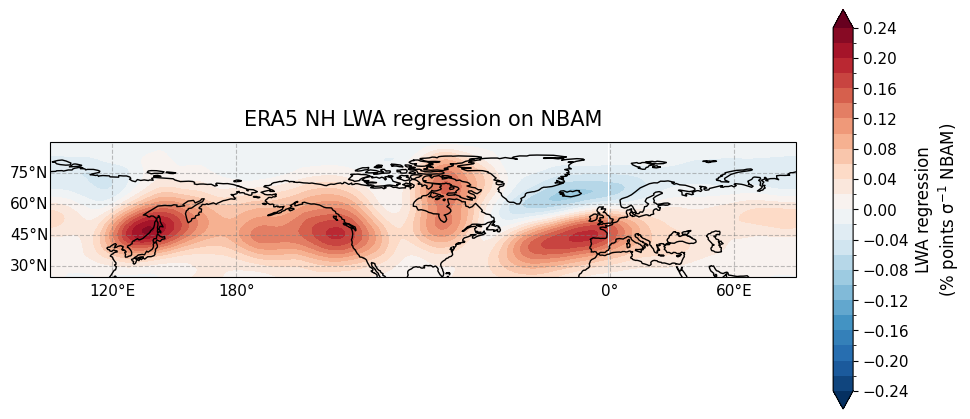

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import BoundaryNorm

# =========================
# Plot settings
# =========================
centralLon = 270

proj = ccrs.PlateCarree(central_longitude=centralLon)  # display projection
pc = ccrs.PlateCarree()                                # data coordinate

fig = plt.figure(figsize=(10, 5))
ax = plt.axes(projection=proj)

# NH lat-lon rectangular map
ax.set_extent([-180, 180, 25, 90], crs=pc)

# land / coastlines
ax.add_feature(
    cfeature.LAND.with_scale("110m"),
    facecolor="0.85",
    edgecolor="none",
    zorder=0
)
ax.coastlines("110m", linewidth=1.0, zorder=5)

# gridlines
gl = ax.gridlines(
    crs=pc,
    draw_labels=True,
    linewidth=0.8,
    color="gray",
    linestyle="--",
    alpha=0.5
)

gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 11}
gl.ylabel_style = {"size": 11}
gl.xlocator = mticker.FixedLocator([0, 60, 120, 180, 240, 300])
gl.ylocator = mticker.FixedLocator([30, 45, 60, 75])

# =========================
# Regression shading
# =========================
levels = np.arange(-0.24, 0.26, 0.02)
cmap = plt.cm.RdBu_r
norm = BoundaryNorm(levels, ncolors=cmap.N, extend="both")

cf = ax.contourf(
    lon, latLWA, slope_pct,
    levels=levels,
    cmap=cmap,
    norm=norm,
    extend="both",
    transform=pc,
    zorder=1
)

# =========================
# Significance stippling / hatching
# =========================
# ax.contourf(
#     lon, latLWA, pval < 0.05,
#     levels=[0.5, 1],
#     hatches=["...", None],
#     colors="none",
#     transform=pc,
#     zorder=4
# )

# =========================
# Colorbar
# =========================
cb = plt.colorbar(
    cf,
    ax=ax,
    orientation="vertical",
    shrink=0.85,
    pad=0.04,
    ticks=levels[::2]
)

cb.set_label("LWA regression\n(% points σ$^{-1}$ NBAM)", fontsize=12)
cb.ax.tick_params(labelsize=11)

# =========================
# Title
# =========================
ax.set_title(
    f"{dtname} {k} LWA regression on NBAM",
    fontsize=15,
    pad=12
)

plt.tight_layout()
plt.show()